# Phase 4 — Final Cross-Dataset Synthesis

**Scope:** EDA, cross-dataset performance comparison, training dynamics, efficiency analysis, and attention interpretability.  
**No retraining** — all results loaded from saved outputs. Attention weights extracted via forward pass on saved checkpoints.

## 0. Setup & Configuration

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import os, sys, json, time, gc, math

from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import acf, pacf

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import warnings
warnings.filterwarnings("ignore")

from models import Seq2SeqBahdanau, SelfAttentionLSTM, TransformerForecaster

SEED    = 42
HORIZON = 96
DEVICE  = "cpu"
np.random.seed(SEED)
torch.manual_seed(SEED)

RESULTS_DIR = "../outputs/results"
LOGS_DIR    = "../outputs/logs"
CONFIG_DIR  = "../outputs/configs"
CKPT_DIR    = "../outputs/checkpoints"
FIGURES_DIR = "../outputs/figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

DATASETS = {
    "etth1": dict(
        name="ETTh1", target="OT", freq="hourly",
        lookback=96, stl_period=24, split_ratio=(0.6, 0.2, 0.2),
        data_path="../data/ETDataset-main/ETT-small/ETTh1.csv",
        character="Multi-scale load cycles",
    ),
    "jena": dict(
        name="Jena Climate", target="T (degC)", freq="hourly",
        lookback=96, stl_period=24, split_ratio=(0.6, 0.2, 0.2),
        data_path="../data/jena_climate_2009_2016.csv",
        character="Strong periodicity (diurnal + annual)",
    ),
    "exchange": dict(
        name="Exchange Rate", target="SGD", freq="daily",
        lookback=30, stl_period=7, split_ratio=(0.7, 0.1, 0.2),
        data_path="../data/multivariate-time-series-data-master/exchange_rate/exchange_rate.txt",
        character="Stochastic / near-random-walk",
    ),
}

DS_KEYS  = ["etth1", "jena", "exchange"]
DS_NAMES = {k: v["name"] for k, v in DATASETS.items()}

MODEL_IDS   = ["bahdanau", "selfattn", "transformer"]
MODEL_NAMES = {"bahdanau": "M1 Bahdanau", "selfattn": "M2 SelfAttn", "transformer": "M3 Transformer"}
MODEL_COLORS = {"bahdanau": "#e74c3c", "selfattn": "#3498db", "transformer": "#2ecc71"}
BASELINE_GRAY = "#999999"

NEURAL_CSV_LABELS = ["LSTM+Bahdanau (M1)", "LSTM+SelfAttn (M2)", "Transformer (M3)"]

def save_fig(fig, name):
    path = os.path.join(FIGURES_DIR, f"final_{name}.png")
    fig.savefig(path, dpi=150, bbox_inches="tight")
    print(f"Saved: {path}")

print(f"Device: {DEVICE}  |  Seed: {SEED}")

Device: cpu  |  Seed: 42


---
## 1. Exploratory Data Analysis

Establishes the **ground-truth temporal structure** of each dataset.  
These EDA figures are later compared against learned attention patterns (Section 5).

### 1a. Raw Time-Series Plots

In [24]:
def load_raw_target(key):
    """Load raw data and return (full_DataFrame, target_Series, split_indices)."""
    meta = DATASETS[key]
    if key == "etth1":
        df = pd.read_csv(meta["data_path"], parse_dates=["date"], index_col="date")
    elif key == "jena":
        raw_10min = pd.read_csv(meta["data_path"], parse_dates=["Date Time"], dayfirst=True)
        raw_10min.set_index("Date Time", inplace=True)
        df = raw_10min.resample("1h").mean()
        del raw_10min
        df.dropna(inplace=True)
    elif key == "exchange":
        cols = ["AUD", "GBP", "CAD", "CHF", "CNY", "JPY", "NZD", "SGD"]
        df = pd.read_csv(meta["data_path"], header=None, names=cols)
        df.index = pd.date_range("1990-01-01", periods=len(df), freq="D")
        df.index.name = "Date"
    n = len(df)
    r = meta["split_ratio"]
    n_train = int(n * r[0])
    n_val   = int(n * r[1])
    splits = {"train_end": n_train, "val_end": n_train + n_val}
    return df, df[meta["target"]], splits

raw_frames = {}
target_series = {}
split_info = {}
for k in DS_KEYS:
    raw_frames[k], target_series[k], split_info[k] = load_raw_target(k)
    m = DATASETS[k]
    print(f"{m['name']:15s}  rows={len(raw_frames[k]):,}  "
          f"target={m['target']}  train_end_idx={split_info[k]['train_end']}")

ETTh1            rows=17,420  target=OT  train_end_idx=10452
Jena Climate     rows=70,041  target=T (degC)  train_end_idx=42024
Exchange Rate    rows=7,588  target=SGD  train_end_idx=5311


Saved: ../outputs/figures/final_raw_timeseries.png


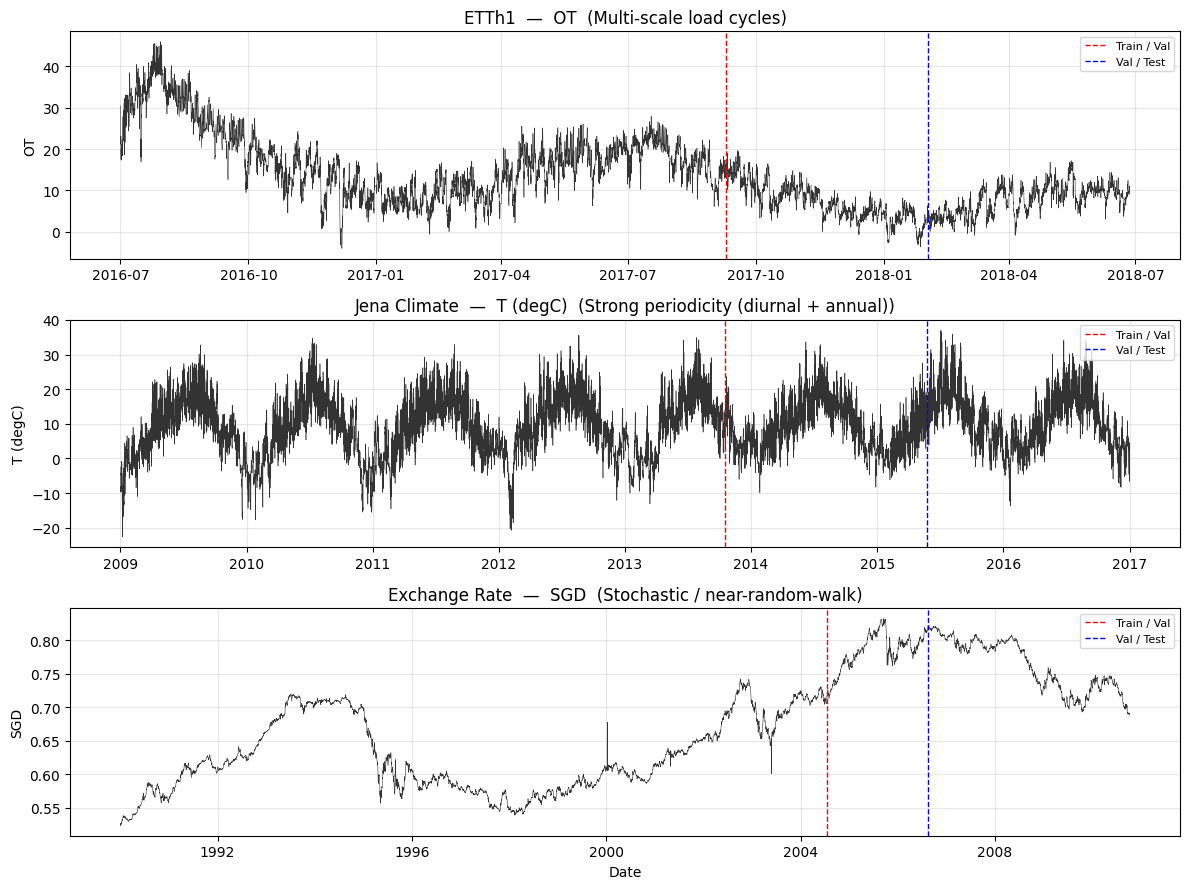

In [25]:
fig, axes = plt.subplots(3, 1, figsize=(12, 9))
for ax, k in zip(axes, DS_KEYS):
    s = target_series[k]
    sp = split_info[k]
    ax.plot(s.index, s.values, linewidth=0.4, color="#333")
    ax.axvline(s.index[sp["train_end"]], color="red", ls="--", lw=1, label="Train / Val")
    ax.axvline(s.index[sp["val_end"]],   color="blue", ls="--", lw=1, label="Val / Test")
    meta = DATASETS[k]
    ax.set_title(f"{meta['name']}  —  {meta['target']}  ({meta['character']})")
    ax.set_ylabel(meta["target"])
    ax.legend(loc="upper right", fontsize=8)
    ax.grid(True, alpha=0.3)
axes[-1].set_xlabel("Date")
plt.tight_layout()
save_fig(fig, "raw_timeseries")
plt.show()

### 1b. STL Seasonal-Trend Decomposition

Saved: ../outputs/figures/final_stl_etth1.png


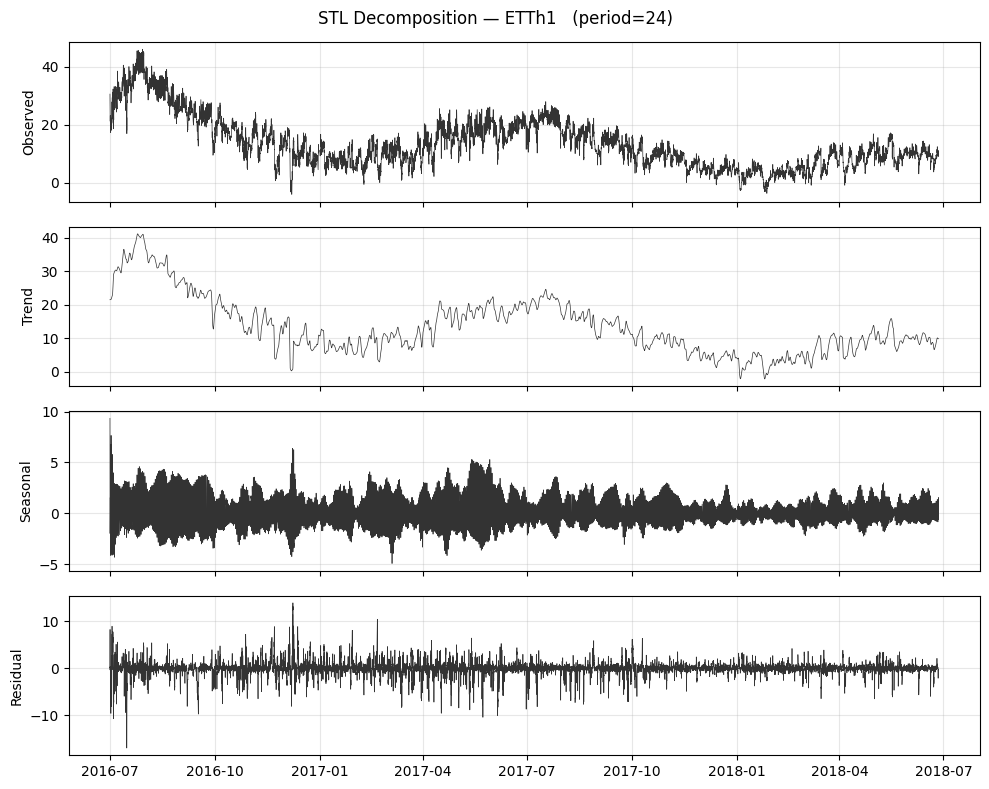

Saved: ../outputs/figures/final_stl_jena.png


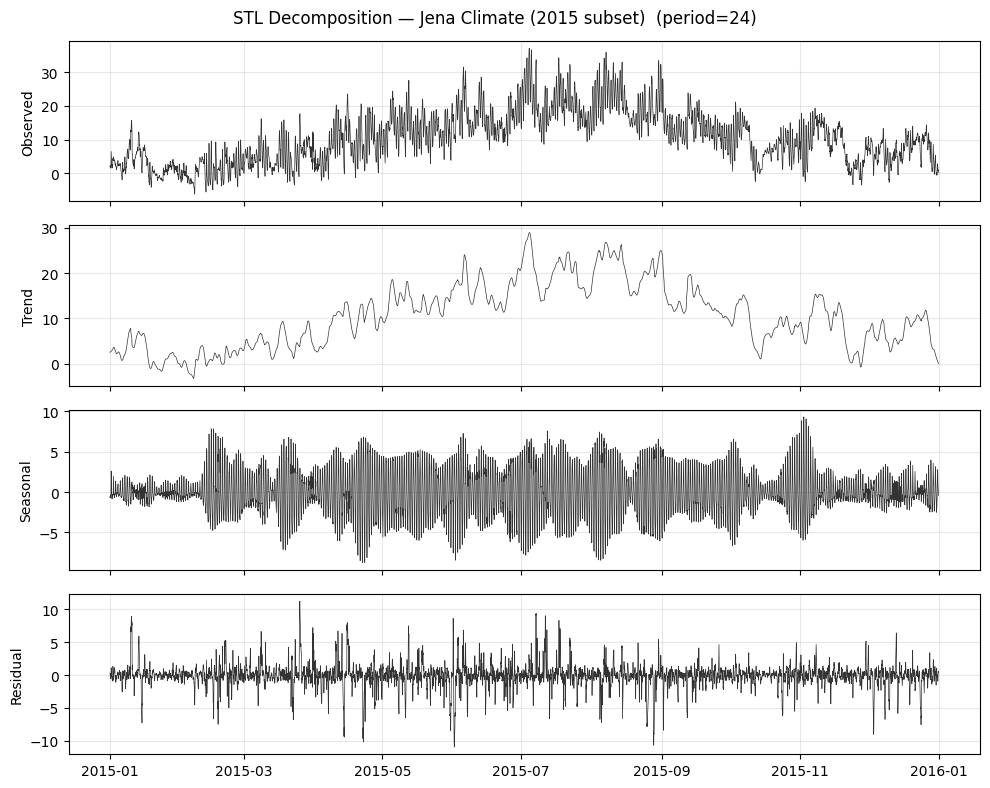

Saved: ../outputs/figures/final_stl_exchange.png


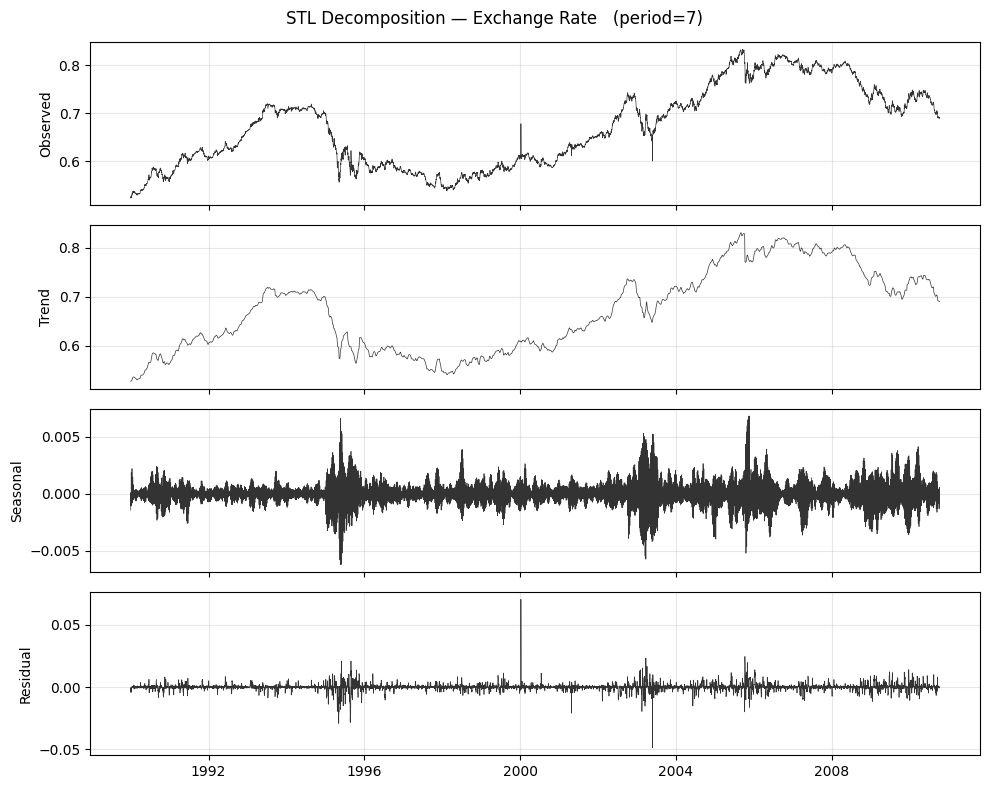

In [26]:
for k in DS_KEYS:
    meta = DATASETS[k]
    s = target_series[k]
    period = meta["stl_period"]

    if k == "jena":
        # Use a 1-year subset to keep STL tractable on 70K rows
        s_sub = s["2015-01-01":"2015-12-31"]
        subtitle = "(2015 subset)"
    else:
        s_sub = s
        subtitle = ""

    stl = STL(s_sub, period=period, robust=True)
    res = stl.fit()

    fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
    for ax, (data, label) in zip(axes, [
        (res.observed, "Observed"), (res.trend, "Trend"),
        (res.seasonal, "Seasonal"), (res.resid, "Residual"),
    ]):
        ax.plot(data, linewidth=0.5, color="#333")
        ax.set_ylabel(label)
        ax.grid(True, alpha=0.3)
    fig.suptitle(f"STL Decomposition — {meta['name']} {subtitle}  (period={period})")
    plt.tight_layout()
    save_fig(fig, f"stl_{k}")
    plt.show()
    del res; gc.collect()

### 1c. ACF / PACF Correlograms

Saved: ../outputs/figures/final_acf_pacf.png


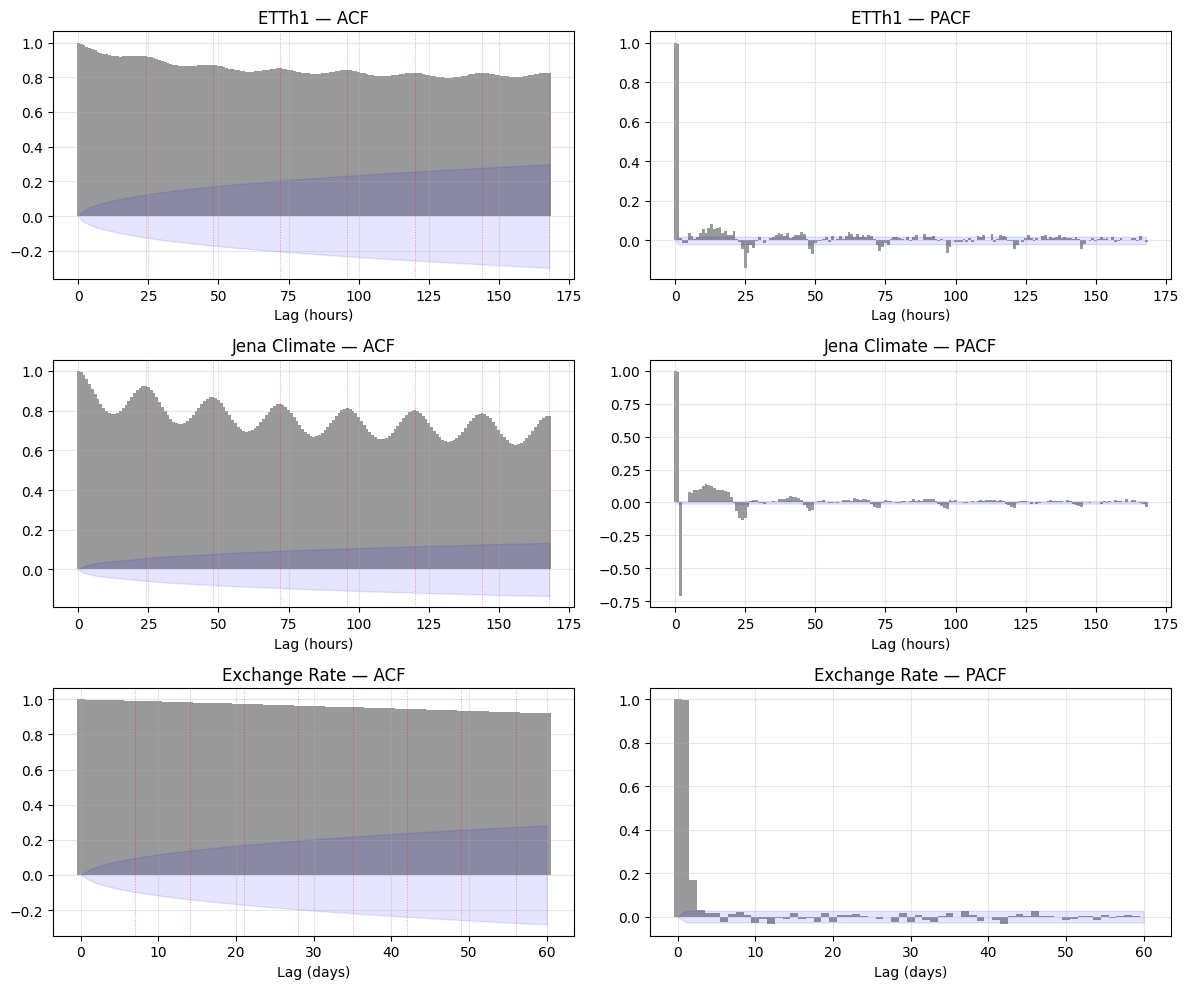

ACF values stored for attention overlay in Section 5.


In [27]:
acf_store = {}

fig, axes = plt.subplots(3, 2, figsize=(12, 10))
for row, k in enumerate(DS_KEYS):
    meta = DATASETS[k]
    s = target_series[k].iloc[:split_info[k]["train_end"]]
    nlags = 168 if meta["freq"] == "hourly" else 60

    acf_vals, acf_ci = acf(s, nlags=nlags, alpha=0.05)
    pacf_vals, pacf_ci = pacf(s, nlags=min(nlags, len(s) // 2 - 1), alpha=0.05)
    acf_store[k] = acf_vals

    lags_acf  = np.arange(len(acf_vals))
    lags_pacf = np.arange(len(pacf_vals))
    unit = "hours" if meta["freq"] == "hourly" else "days"

    ax_acf = axes[row, 0]
    ax_acf.bar(lags_acf, acf_vals, width=1, color="#555", alpha=0.6)
    ax_acf.fill_between(lags_acf, acf_ci[:, 0] - acf_vals, acf_ci[:, 1] - acf_vals,
                        alpha=0.1, color="blue")
    ax_acf.set_title(f"{meta['name']} — ACF")
    ax_acf.set_xlabel(f"Lag ({unit})")
    ax_acf.grid(True, alpha=0.3)

    ax_pacf = axes[row, 1]
    ax_pacf.bar(lags_pacf, pacf_vals, width=1, color="#555", alpha=0.6)
    ax_pacf.fill_between(lags_pacf, pacf_ci[:, 0] - pacf_vals, pacf_ci[:, 1] - pacf_vals,
                         alpha=0.1, color="blue")
    ax_pacf.set_title(f"{meta['name']} — PACF")
    ax_pacf.set_xlabel(f"Lag ({unit})")
    ax_pacf.grid(True, alpha=0.3)

    period = meta["stl_period"]
    for mult in range(1, nlags // period + 1):
        lag = mult * period
        if lag <= nlags:
            ax_acf.axvline(lag, color="red", ls=":", lw=0.7, alpha=0.4)

plt.tight_layout()
save_fig(fig, "acf_pacf")
plt.show()

print("ACF values stored for attention overlay in Section 5.")

In [28]:
# Free EDA data — raw frames no longer needed until Section 5
del target_series
gc.collect()
print("Freed target_series. raw_frames kept for Section 5 data prep.")

Freed target_series. raw_frames kept for Section 5 data prep.


---
## 2. Cross-Dataset Performance Summary

Which attention mechanism performs best — and does it depend on the dataset?

In [29]:
result_frames = []
for k in DS_KEYS:
    df = pd.read_csv(os.path.join(RESULTS_DIR, f"{k}_96_comparison.csv"))
    df.insert(0, "Dataset", DS_NAMES[k])
    result_frames.append(df)

all_results = pd.concat(result_frames, ignore_index=True)
all_results.to_csv(os.path.join(RESULTS_DIR, "final_unified_comparison.csv"), index=False)
print("Unified comparison table:")
all_results

Unified comparison table:


,Dataset,Model,MSE_scaled,MAE_scaled,MSE_original,MAE_original
0,ETTh1,Persistence,0.129382,0.273832,9.3779,2.3313
1,ETTh1,Seasonal Naive 24h,0.140399,0.288135,10.1765,2.4531
2,ETTh1,Linear Regression,0.117399,0.263312,8.5094,2.2418
3,ETTh1,LSTM+Bahdanau (M1),0.178013,0.345939,12.9028,2.9452
4,ETTh1,LSTM+SelfAttn (M2),0.093443,0.234754,6.7730,1.9986
5,ETTh1,Transformer (M3),0.194951,0.365888,14.1306,3.1150
6,Jena Climate,Persistence,0.391768,0.480963,30.5126,4.2446
7,Jena Climate,Seasonal Naive 24h,0.268424,0.397489,20.9060,3.5079
8,Jena Climate,Linear Regression,7.712432,0.497687,600.6777,4.3922
9,Jena Climate,LSTM+Bahdanau (M1),0.186744,0.335410,14.5444,2.9601


### 2c. Cross-Dataset MSE Bar Chart

The proposal planned horizon-wise bar charts.  Since only h=96 is available, the x-axis is **datasets** instead of horizons.

Saved: ../outputs/figures/final_cross_dataset_mse_bars.png


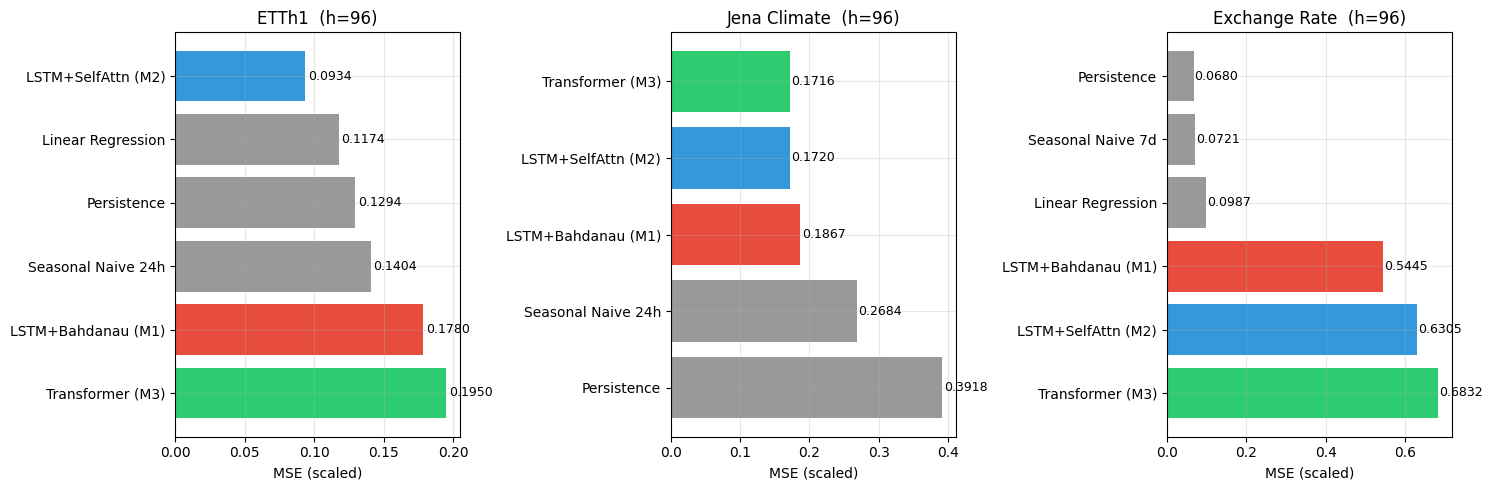

In [30]:
# Build a tidy list of (label, MSE, color) per dataset for horizontal bars
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, k in zip(axes, DS_KEYS):
    sub = all_results[all_results["Dataset"] == DS_NAMES[k]].copy()
    # Drop Linear Regression if it's an extreme outlier (Jena LR MSE > 7)
    sub = sub[sub["MSE_scaled"] < 2.0]
    sub = sub.sort_values("MSE_scaled", ascending=True)

    names = sub["Model"].tolist()
    mses  = sub["MSE_scaled"].values
    colors = []
    for name in names:
        if "Bahdanau" in name:    colors.append(MODEL_COLORS["bahdanau"])
        elif "SelfAttn" in name:  colors.append(MODEL_COLORS["selfattn"])
        elif "Transformer" in name: colors.append(MODEL_COLORS["transformer"])
        else:                     colors.append(BASELINE_GRAY)

    ax.barh(names, mses, color=colors)
    ax.set_xlabel("MSE (scaled)")
    ax.set_title(f"{DS_NAMES[k]}  (h=96)")
    ax.invert_yaxis()
    for i, v in enumerate(mses):
        ax.text(v + 0.002, i, f"{v:.4f}", va="center", fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
save_fig(fig, "cross_dataset_mse_bars")
plt.show()

### 2d. Summary Heatmap — Datasets × Models

Saved: ../outputs/figures/final_summary_heatmap.png


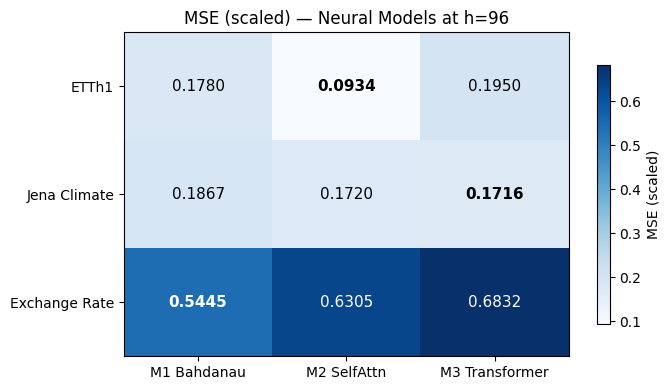

In [31]:
heatmap_data = np.zeros((3, 3))

for i, k in enumerate(DS_KEYS):
    for j, ml in enumerate(NEURAL_CSV_LABELS):
        sub = all_results[(all_results["Dataset"] == DS_NAMES[k]) & (all_results["Model"] == ml)]
        heatmap_data[i, j] = sub["MSE_scaled"].values[0]

row_labels = [DS_NAMES[k] for k in DS_KEYS]
col_labels = [MODEL_NAMES[m] for m in MODEL_IDS]

fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(heatmap_data, cmap="Blues", aspect="auto")
plt.colorbar(im, ax=ax, shrink=0.8, label="MSE (scaled)")

for i in range(3):
    for j in range(3):
        val = heatmap_data[i, j]
        best_in_row = val == heatmap_data[i].min()
        ax.text(j, i, f"{val:.4f}", ha="center", va="center", fontsize=11,
                fontweight="bold" if best_in_row else "normal",
                color="white" if val > heatmap_data.mean() else "black")

ax.set_xticks(range(3))
ax.set_xticklabels(col_labels)
ax.set_yticks(range(3))
ax.set_yticklabels(row_labels)
ax.set_title("MSE (scaled) — Neural Models at h=96")
plt.tight_layout()
save_fig(fig, "summary_heatmap")
plt.show()

---
## 3. Training Dynamics

Which models train stably, which overfit, and how quickly do they converge?

In [32]:
# Load all training logs
logs = {}
for k in DS_KEYS:
    logs[k] = {}
    for m in MODEL_IDS:
        path = os.path.join(LOGS_DIR, f"{k}_96_{m}_log.csv")
        logs[k][m] = pd.read_csv(path)
        print(f"{k:10s} {m:12s}  epochs={len(logs[k][m])}")

etth1      bahdanau      epochs=11
etth1      selfattn      epochs=26
etth1      transformer   epochs=11
jena       bahdanau      epochs=11
jena       selfattn      epochs=30
jena       transformer   epochs=11
exchange   bahdanau      epochs=11
exchange   selfattn      epochs=16
exchange   transformer   epochs=14


### 3b. Training & Validation Loss Curves

Saved: ../outputs/figures/final_loss_curves.png


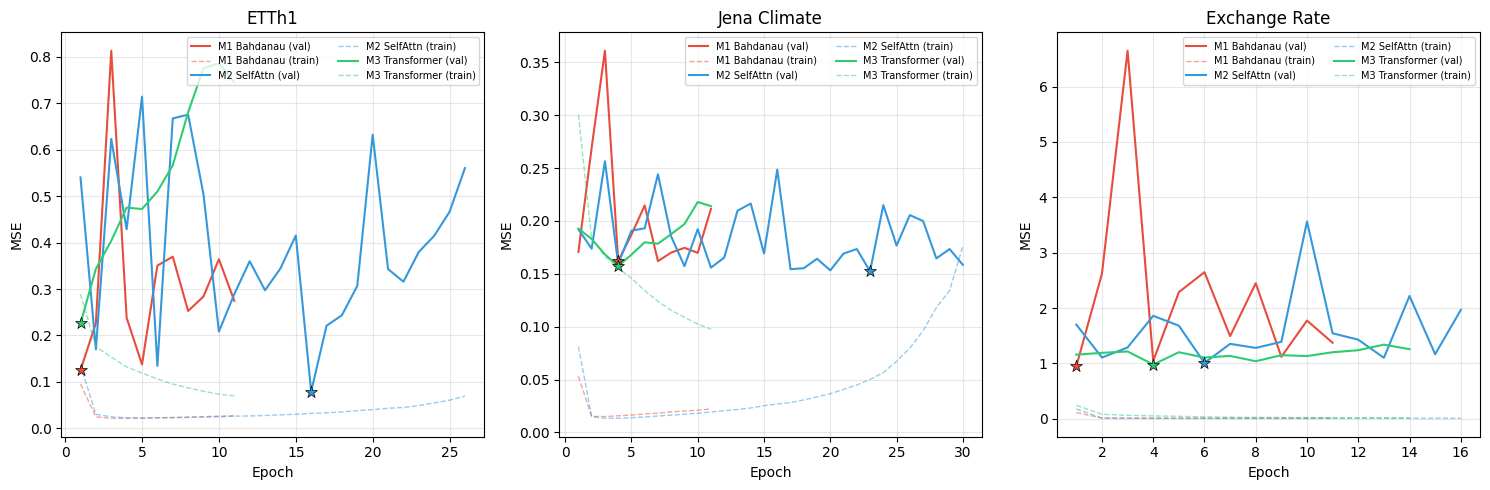

In [33]:
# Load configs for best-epoch markers
configs = {}
for k in DS_KEYS:
    configs[k] = {}
    for m in MODEL_IDS:
        with open(os.path.join(CONFIG_DIR, f"{k}_96_{m}.json")) as f:
            configs[k][m] = json.load(f)

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)
for ax, k in zip(axes, DS_KEYS):
    for m in MODEL_IDS:
        log = logs[k][m]
        c = MODEL_COLORS[m]
        best_ep = configs[k][m]["best_epoch"]
        epochs = log["epoch"]
        ax.plot(epochs, log["val_mse"], color=c, linewidth=1.5,
                label=f"{MODEL_NAMES[m]} (val)")
        ax.plot(epochs, log["train_mse"], color=c, linewidth=1,
                linestyle="--", alpha=0.5, label=f"{MODEL_NAMES[m]} (train)")
        ax.scatter([best_ep], [log.loc[log["epoch"] == best_ep, "val_mse"].values[0]],
                   marker="*", s=80, color=c, zorder=5, edgecolors="k", linewidths=0.5)
    ax.set_title(DS_NAMES[k])
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MSE")
    ax.legend(fontsize=7, ncol=2)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
save_fig(fig, "loss_curves")
plt.show()

### 3c. Convergence Summary Table

In [34]:
rows = []
for k in DS_KEYS:
    for m in MODEL_IDS:
        cfg = configs[k][m]
        log = logs[k][m]
        best_ep = cfg["best_epoch"]
        best_row = log[log["epoch"] == best_ep].iloc[0]
        overfit_ratio = best_row["train_mse"] / best_row["val_mse"]
        rows.append({
            "Dataset": DS_NAMES[k],
            "Model": MODEL_NAMES[m],
            "Params": f"{cfg['total_params']:,}",
            "Best Epoch": best_ep,
            "Epochs Run": len(log),
            "Best Val MSE": round(cfg["best_val_mse"], 4),
            "Train Time (s)": round(cfg["training_time_s"], 1),
            "Overfit Ratio": round(overfit_ratio, 3),
        })

convergence_df = pd.DataFrame(rows)
convergence_df.to_csv(os.path.join(RESULTS_DIR, "final_convergence_summary.csv"), index=False)
print("Overfit Ratio = train_MSE / val_MSE at best epoch (near 1.0 = healthy, <<1 = overfitting)")
convergence_df

Overfit Ratio = train_MSE / val_MSE at best epoch (near 1.0 = healthy, <<1 = overfitting)


,Dataset,Model,Params,Best Epoch,Epochs Run,Best Val MSE,Train Time (s),Overfit Ratio
0,ETTh1,M1 Bahdanau,"95,361",1,11,0.1254,529.9,0.761
1,ETTh1,M2 SelfAttn,"94,921",16,26,0.0792,1137.2,0.408
2,ETTh1,M3 Transformer,"94,945",1,11,0.2260,167.1,1.280
3,Jena Climate,M1 Bahdanau,"97,409",4,11,0.1620,2032.0,0.097
4,Jena Climate,M2 SelfAttn,"96,841",23,30,0.1523,4996.2,0.329
5,Jena Climate,M3 Transformer,"95,457",4,11,0.1573,663.9,0.986
6,Exchange Rate,M1 Bahdanau,"95,105",1,11,0.9486,191.4,0.119
7,Exchange Rate,M2 SelfAttn,"94,681",6,16,1.0092,256.6,0.009
8,Exchange Rate,M3 Transformer,"94,881",4,14,0.9799,94.3,0.054


---
## 4. Efficiency Analysis

Quantifying the accuracy-vs-cost tradeoff.

### 4b. Inference Latency Measurement

Timed forward passes on saved checkpoints.  100 passes per model after 10 warm-up passes.

In [35]:
def preprocess_for_inference(raw_df, meta, ds_key):
    """Replicate exact preprocessing from training notebooks.
    Returns (test_data_array, n_features, target_idx)."""
    df = raw_df.copy()
    target = meta["target"]
    r = meta["split_ratio"]
    n = len(df)
    n_train = int(n * r[0])
    n_val   = int(n * r[1])

    # Jena: encode circular wind direction as sin/cos (matches training notebook)
    if ds_key == "jena" and "wd (deg)" in df.columns:
        df["wd_sin"] = np.sin(np.deg2rad(df["wd (deg)"]))
        df["wd_cos"] = np.cos(np.deg2rad(df["wd (deg)"]))
        df.drop(columns=["wd (deg)"], inplace=True)

    feature_cols = [c for c in df.columns if c != target]
    all_cols = feature_cols + [target]
    scaler = StandardScaler()
    scaler.fit(df.iloc[:n_train][all_cols])

    scaled = pd.DataFrame(scaler.transform(df[all_cols]),
                          index=df.index, columns=all_cols)

    idx = scaled.index
    if meta["freq"] == "hourly":
        scaled["hour_sin"]  = np.sin(2 * np.pi * idx.hour / 24)
        scaled["hour_cos"]  = np.cos(2 * np.pi * idx.hour / 24)
    scaled["dow_sin"]   = np.sin(2 * np.pi * idx.dayofweek / 7)
    scaled["dow_cos"]   = np.cos(2 * np.pi * idx.dayofweek / 7)
    scaled["month_sin"] = np.sin(2 * np.pi * idx.month / 12)
    scaled["month_cos"] = np.cos(2 * np.pi * idx.month / 12)

    target_idx = scaled.columns.get_loc(target)
    n_features = scaled.shape[1]
    arr = scaled.values.astype(np.float32)
    test_data = arr[n_train + n_val:]

    del scaled, arr; gc.collect()
    return test_data, n_features, target_idx


def build_model(model_id, n_features, target_idx, cfg):
    """Instantiate a model from its config."""
    if model_id == "bahdanau":
        return Seq2SeqBahdanau(
            n_features, cfg["hidden_dim"], cfg["enc_layers"],
            HORIZON, target_idx, cfg["dropout"])
    elif model_id == "selfattn":
        return SelfAttentionLSTM(
            n_features, cfg["hidden_dim"], cfg["enc_layers"],
            HORIZON, target_idx, cfg["dropout"])
    elif model_id == "transformer":
        return TransformerForecaster(
            n_features, cfg["d_model"], cfg["n_heads"],
            cfg["n_layers"], cfg["dim_ff"], HORIZON, cfg["dropout"])


print("Helper functions defined.")

Helper functions defined.


In [36]:
BATCH_LATENCY = 64
N_WARMUP = 10
N_TIMED  = 100

latency_rows = []
for k in DS_KEYS:
    meta = DATASETS[k]
    test_data, n_features, target_idx = preprocess_for_inference(raw_frames[k], meta, k)
    lookback = meta["lookback"]

    # Build one batch of test windows
    windows = []
    for i in range(BATCH_LATENCY):
        if i + lookback + HORIZON <= len(test_data):
            windows.append(test_data[i : i + lookback])
    X_batch = torch.tensor(np.stack(windows), dtype=torch.float32)
    print(f"{meta['name']:15s}  batch shape={X_batch.shape}  n_features={n_features}")

    for m in MODEL_IDS:
        cfg = configs[k][m]
        model = build_model(m, n_features, target_idx, cfg)
        ckpt = torch.load(os.path.join(CKPT_DIR, f"{k}_96_{m}.pt"),
                          map_location=DEVICE, weights_only=True)
        model.load_state_dict(ckpt)
        model.eval()

        with torch.no_grad():
            for _ in range(N_WARMUP):
                _ = model(X_batch)

            times = []
            for _ in range(N_TIMED):
                t0 = time.perf_counter()
                _ = model(X_batch)
                times.append(time.perf_counter() - t0)

        mean_ms = np.mean(times) * 1000
        std_ms  = np.std(times) * 1000
        per_sample = mean_ms / X_batch.shape[0]
        latency_rows.append({
            "Dataset": DS_NAMES[k], "Model": MODEL_NAMES[m],
            "Batch Latency (ms)": round(mean_ms, 2),
            "Std (ms)": round(std_ms, 2),
            "Per-Sample (ms)": round(per_sample, 3),
        })
        print(f"  {MODEL_NAMES[m]:18s}  {mean_ms:7.2f} \u00b1 {std_ms:.2f} ms/batch  |  {per_sample:.3f} ms/sample")
        del model, ckpt; gc.collect()

    del test_data, X_batch; gc.collect()

latency_df = pd.DataFrame(latency_rows)
latency_df.to_csv(os.path.join(RESULTS_DIR, "final_inference_latency.csv"), index=False)
latency_df

ETTh1            batch shape=torch.Size([64, 96, 13])  n_features=13
  M1 Bahdanau           97.90 ± 18.58 ms/batch  |  1.530 ms/sample
  M2 SelfAttn           87.11 ± 9.29 ms/batch  |  1.361 ms/sample
  M3 Transformer        11.46 ± 0.54 ms/batch  |  0.179 ms/sample
Jena Climate     batch shape=torch.Size([64, 96, 21])  n_features=21
  M1 Bahdanau           87.43 ± 5.04 ms/batch  |  1.366 ms/sample
  M2 SelfAttn           92.88 ± 15.19 ms/batch  |  1.451 ms/sample
  M3 Transformer        13.76 ± 1.12 ms/batch  |  0.215 ms/sample
Exchange Rate    batch shape=torch.Size([64, 30, 12])  n_features=12
  M1 Bahdanau           40.20 ± 1.98 ms/batch  |  0.628 ms/sample
  M2 SelfAttn           36.77 ± 1.70 ms/batch  |  0.575 ms/sample
  M3 Transformer         7.43 ± 0.66 ms/batch  |  0.116 ms/sample


,Dataset,Model,Batch Latency (ms),Std (ms),Per-Sample (ms)
0,ETTh1,M1 Bahdanau,97.90,18.58,1.530
1,ETTh1,M2 SelfAttn,87.11,9.29,1.361
2,ETTh1,M3 Transformer,11.46,0.54,0.179
3,Jena Climate,M1 Bahdanau,87.43,5.04,1.366
4,Jena Climate,M2 SelfAttn,92.88,15.19,1.451
5,Jena Climate,M3 Transformer,13.76,1.12,0.215
6,Exchange Rate,M1 Bahdanau,40.20,1.98,0.628
7,Exchange Rate,M2 SelfAttn,36.77,1.70,0.575
8,Exchange Rate,M3 Transformer,7.43,0.66,0.116


### 4c. Accuracy vs. Efficiency Scatter Plot

Saved: ../outputs/figures/final_accuracy_vs_efficiency.png


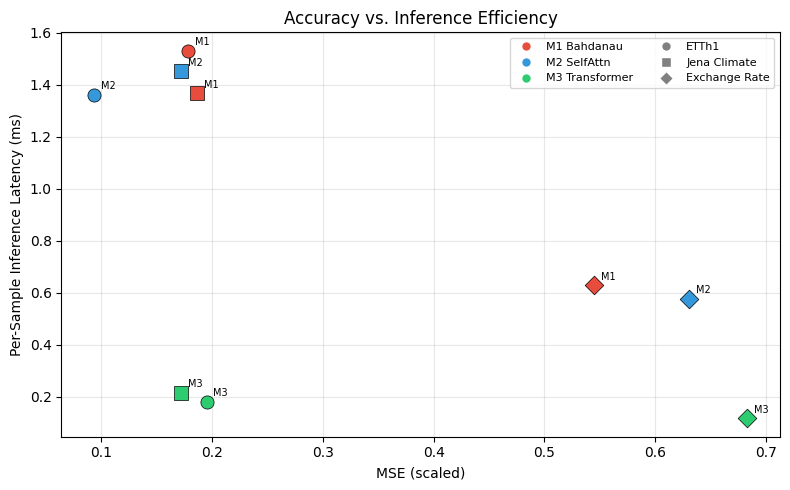

In [37]:
ds_markers = {"etth1": "o", "jena": "s", "exchange": "D"}

fig, ax = plt.subplots(figsize=(8, 5))
for k in DS_KEYS:
    for m in MODEL_IDS:
        mse = all_results[
            (all_results["Dataset"] == DS_NAMES[k]) &
            (all_results["Model"] == NEURAL_CSV_LABELS[MODEL_IDS.index(m)])
        ]["MSE_scaled"].values[0]
        lat = latency_df[
            (latency_df["Dataset"] == DS_NAMES[k]) &
            (latency_df["Model"] == MODEL_NAMES[m])
        ]["Per-Sample (ms)"].values[0]
        ax.scatter(mse, lat, s=90, c=MODEL_COLORS[m], marker=ds_markers[k],
                   edgecolors="k", linewidths=0.5, zorder=5)
        ax.annotate(f"{MODEL_NAMES[m][:2]}", (mse, lat),
                    textcoords="offset points", xytext=(5, 4), fontsize=7)

from matplotlib.lines import Line2D
model_handles = [Line2D([0], [0], marker="o", color="w", markerfacecolor=MODEL_COLORS[m],
                        markersize=7, label=MODEL_NAMES[m]) for m in MODEL_IDS]
ds_handles = [Line2D([0], [0], marker=ds_markers[k], color="w", markerfacecolor="gray",
                     markersize=7, label=DS_NAMES[k]) for k in DS_KEYS]
ax.legend(handles=model_handles + ds_handles, fontsize=8, ncol=2)

ax.set_xlabel("MSE (scaled)")
ax.set_ylabel("Per-Sample Inference Latency (ms)")
ax.set_title("Accuracy vs. Inference Efficiency")
ax.grid(True, alpha=0.3)
plt.tight_layout()
save_fig(fig, "accuracy_vs_efficiency")
plt.show()

---
## 5. Attention Interpretability Analysis

The central analysis of the project.  
Extract attention weight matrices from saved checkpoints and compare to known temporal structure (ACF).

### 5a–b. Prepare Test Batches & Extract Attention Weights

In [38]:
ATTN_BATCH = 32
attn_maps = {}  # attn_maps[ds][model] = np.array

for k in DS_KEYS:
    meta = DATASETS[k]
    test_data, n_features, target_idx = preprocess_for_inference(raw_frames[k], meta, k)
    lookback = meta["lookback"]

    # First ATTN_BATCH windows from test set
    windows = []
    for i in range(ATTN_BATCH):
        if i + lookback + HORIZON <= len(test_data):
            windows.append(test_data[i : i + lookback])
    X = torch.tensor(np.stack(windows), dtype=torch.float32)
    print(f"\n--- {meta['name']} ---  X shape: {X.shape}")

    attn_maps[k] = {}

    for m in MODEL_IDS:
        cfg = configs[k][m]
        model = build_model(m, n_features, target_idx, cfg)
        ckpt = torch.load(os.path.join(CKPT_DIR, f"{k}_96_{m}.pt"),
                          map_location=DEVICE, weights_only=True)
        model.load_state_dict(ckpt)
        model.eval()

        with torch.no_grad():
            if m == "bahdanau":
                _, attn_w = model(X, return_attn=True)
                # attn_w: (B, horizon, lookback)
                attn_maps[k][m] = attn_w.mean(dim=0).numpy()
                print(f"  {MODEL_NAMES[m]:18s}  decoder_attn shape: {attn_w.shape}")

            elif m == "selfattn":
                _, dec_attn, sa_weights = model(X, return_attn=True)
                # dec_attn: (B, horizon, lookback), sa_weights: (B, lookback, lookback)
                attn_maps[k]["selfattn_decoder"] = dec_attn.mean(dim=0).numpy()
                attn_maps[k]["selfattn_self"]    = sa_weights.mean(dim=0).numpy()
                attn_maps[k][m] = dec_attn.mean(dim=0).numpy()
                print(f"  {MODEL_NAMES[m]:18s}  decoder_attn: {dec_attn.shape}  self_attn: {sa_weights.shape}")

            elif m == "transformer":
                # M3 returns (preds, None) — use hook on cross-attention
                cross_attn_weights = []
                def hook_fn(module, inp, out):
                    # nn.MultiheadAttention returns (attn_output, attn_output_weights)
                    if isinstance(out, tuple) and len(out) == 2 and out[1] is not None:
                        cross_attn_weights.append(out[1].detach())

                handle = model.transformer_decoder.layers[0].multihead_attn.register_forward_hook(hook_fn)
                _ = model(X)
                handle.remove()

                if cross_attn_weights:
                    w = cross_attn_weights[0]  # (B, horizon, lookback)
                    attn_maps[k][m] = w.mean(dim=0).numpy()
                    print(f"  {MODEL_NAMES[m]:18s}  cross_attn (via hook): {w.shape}")
                else:
                    print(f"  {MODEL_NAMES[m]:18s}  \u26a0 Cross-attention hook returned no weights")
                    attn_maps[k][m] = None

        del model, ckpt; gc.collect()

    del test_data, X; gc.collect()

# Free raw_frames — no longer needed
del raw_frames; gc.collect()
print("\nAttention extraction complete. raw_frames freed.")


--- ETTh1 ---  X shape: torch.Size([32, 96, 13])
  M1 Bahdanau         decoder_attn shape: torch.Size([32, 96, 96])
  M2 SelfAttn         decoder_attn: torch.Size([32, 96, 96])  self_attn: torch.Size([32, 96, 96])
  M3 Transformer      ⚠ Cross-attention hook returned no weights

--- Jena Climate ---  X shape: torch.Size([32, 96, 21])
  M1 Bahdanau         decoder_attn shape: torch.Size([32, 96, 96])
  M2 SelfAttn         decoder_attn: torch.Size([32, 96, 96])  self_attn: torch.Size([32, 96, 96])
  M3 Transformer      ⚠ Cross-attention hook returned no weights

--- Exchange Rate ---  X shape: torch.Size([32, 30, 12])
  M1 Bahdanau         decoder_attn shape: torch.Size([32, 96, 30])
  M2 SelfAttn         decoder_attn: torch.Size([32, 96, 30])  self_attn: torch.Size([32, 30, 30])
  M3 Transformer      ⚠ Cross-attention hook returned no weights

Attention extraction complete. raw_frames freed.


### 5c. Attention Weight Heatmaps

Saved: ../outputs/figures/final_attention_heatmaps.png


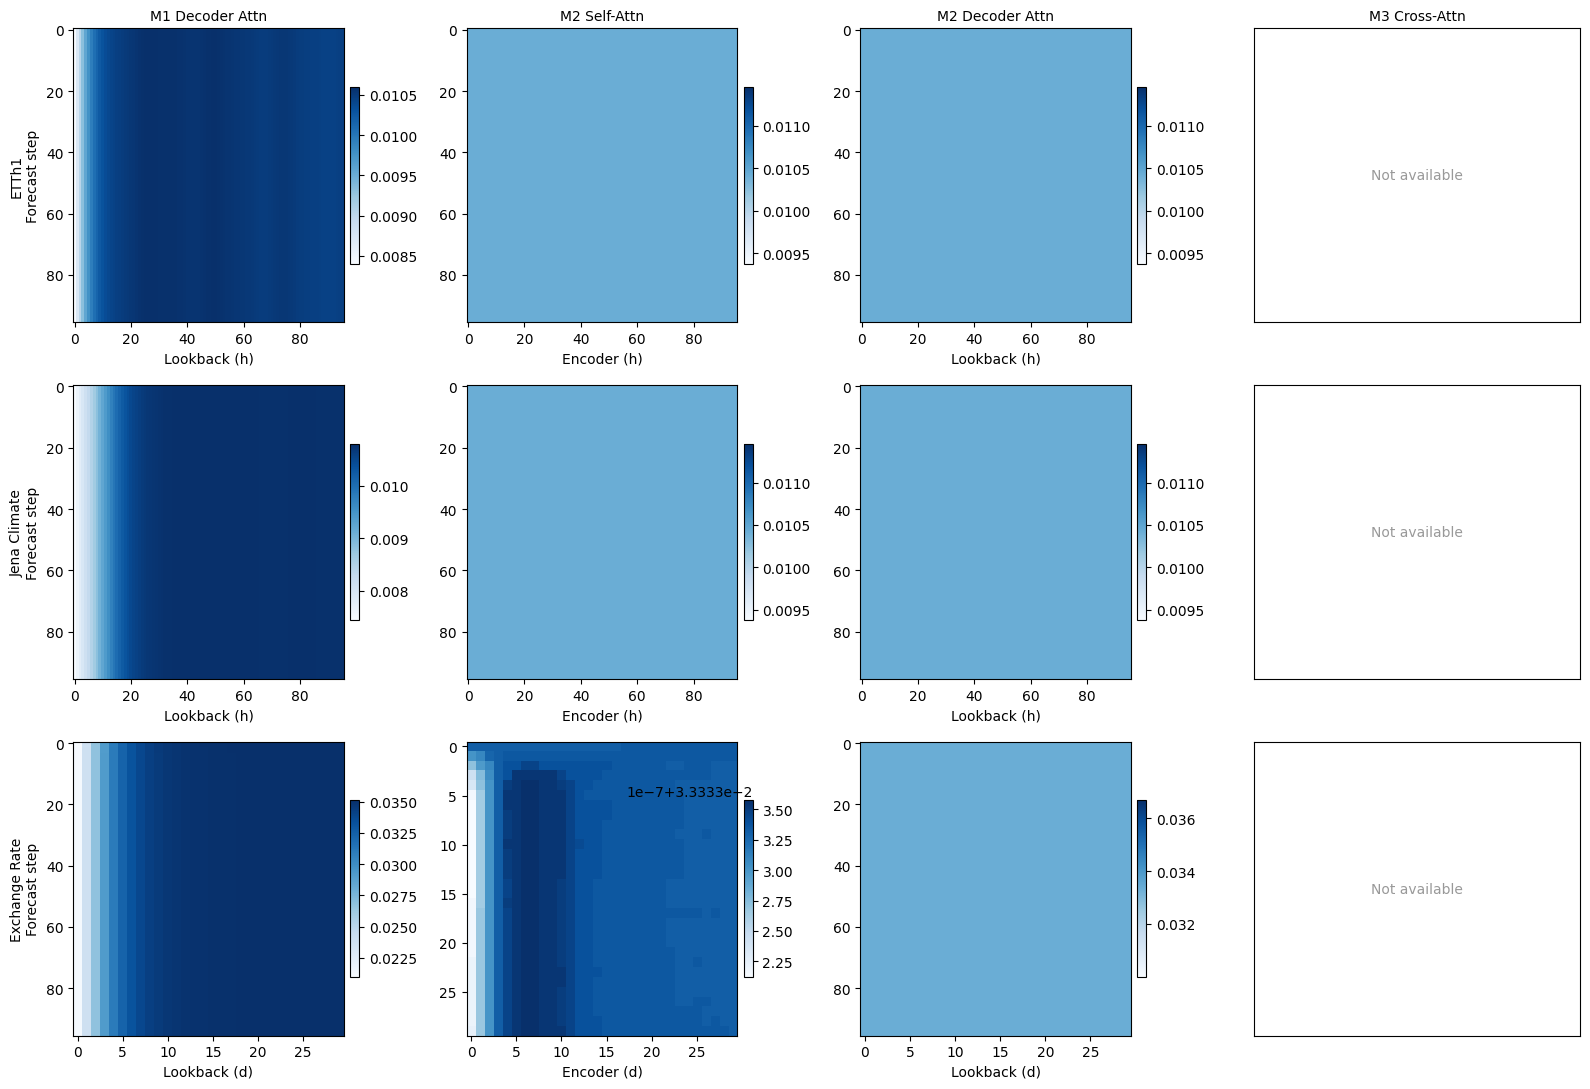

In [39]:
col_specs = [
    ("bahdanau",         "M1 Decoder Attn"),
    ("selfattn_self",    "M2 Self-Attn"),
    ("selfattn_decoder", "M2 Decoder Attn"),
    ("transformer",      "M3 Cross-Attn"),
]

fig, axes = plt.subplots(3, 4, figsize=(16, 11))

for row, k in enumerate(DS_KEYS):
    meta = DATASETS[k]
    unit = "h" if meta["freq"] == "hourly" else "d"

    for col, (key, title) in enumerate(col_specs):
        ax = axes[row, col]
        w = attn_maps[k].get(key)

        if w is None:
            ax.text(0.5, 0.5, "Not available", ha="center", va="center",
                    fontsize=10, color="#999", transform=ax.transAxes)
            ax.set_xticks([]); ax.set_yticks([])
            if row == 0: ax.set_title(title, fontsize=10)
            if col == 0: ax.set_ylabel(meta["name"], fontsize=10)
            continue

        im = ax.imshow(w, aspect="auto", cmap="Blues", interpolation="nearest")
        fig.colorbar(im, ax=ax, shrink=0.6, pad=0.02)

        if key == "selfattn_self":
            ax.set_xlabel(f"Encoder ({unit})")
            if col == 0: ax.set_ylabel(f"{meta['name']}\nEncoder ({unit})", fontsize=10)
        else:
            ax.set_xlabel(f"Lookback ({unit})")
            if col == 0: ax.set_ylabel(f"{meta['name']}\nForecast step", fontsize=10)

        if row == 0:
            ax.set_title(title, fontsize=10)

plt.tight_layout()
save_fig(fig, "attention_heatmaps")
plt.show()

### 5d. Attention Entropy & Peak Lag Analysis

In [40]:
def attention_entropy(w):
    """Shannon entropy of attention weights, averaged across decode steps.
    w: (horizon, lookback) for decoder attn."""
    eps = 1e-10
    H = -np.sum(w * np.log(w + eps), axis=-1)  # per decode step
    return float(np.mean(H))

def peak_lag(w):
    """Lag with highest average attention across all decode steps.
    w: (horizon, lookback). Returns (lag_index, weight_at_peak)."""
    avg = w.mean(axis=0)  # average over decode steps
    peak = int(np.argmax(avg))
    return peak, float(avg[peak])

attn_metric_rows = []
for k in DS_KEYS:
    meta = DATASETS[k]
    lookback = meta["lookback"]
    max_entropy = np.log(lookback)
    unit = "hours" if meta["freq"] == "hourly" else "days"

    for m in ["bahdanau", "selfattn", "transformer"]:
        w = attn_maps[k].get(m)
        if w is None:
            attn_metric_rows.append({
                "Dataset": DS_NAMES[k], "Model": MODEL_NAMES[m],
                "Mean Entropy": np.nan, "Normalized Entropy": np.nan,
                "Peak Lag (idx)": np.nan, f"Peak Lag ({unit})": np.nan,
                "Peak Weight": np.nan,
            })
            continue

        H = attention_entropy(w)
        p_idx, p_weight = peak_lag(w)
        attn_metric_rows.append({
            "Dataset": DS_NAMES[k], "Model": MODEL_NAMES[m],
            "Mean Entropy": round(H, 4),
            "Normalized Entropy": round(H / max_entropy, 4),
            "Peak Lag (idx)": p_idx,
            f"Peak Lag ({unit})": p_idx,
            "Peak Weight": round(p_weight, 4),
        })

attn_metrics_df = pd.DataFrame(attn_metric_rows)
attn_metrics_df.to_csv(os.path.join(RESULTS_DIR, "final_attention_metrics.csv"), index=False)
attn_metrics_df

,Dataset,Model,Mean Entropy,Normalized Entropy,Peak Lag (idx),Peak Lag (hours),Peak Weight,Peak Lag (days)
0,ETTh1,M1 Bahdanau,4.5637,0.9999,27.0,27.0,0.0106,NaN
1,ETTh1,M2 SelfAttn,4.5643,1.0000,0.0,0.0,0.0104,NaN
2,ETTh1,M3 Transformer,NaN,NaN,NaN,NaN,NaN,NaN
3,Jena Climate,M1 Bahdanau,4.5610,0.9993,57.0,57.0,0.0108,NaN
4,Jena Climate,M2 SelfAttn,4.5643,1.0000,0.0,0.0,0.0104,NaN
5,Jena Climate,M3 Transformer,NaN,NaN,NaN,NaN,NaN,NaN
6,Exchange Rate,M1 Bahdanau,3.3952,0.9982,24.0,NaN,0.0351,24.0
7,Exchange Rate,M2 SelfAttn,3.4012,1.0000,0.0,NaN,0.0333,0.0
8,Exchange Rate,M3 Transformer,NaN,NaN,NaN,NaN,NaN,NaN


In [41]:
# Entropy values are captured in the table above.
# A bar chart was omitted because normalized entropy is near 1.0 for all
# models on all datasets (attention is broadly diffuse), making the chart
# visually uninformative — the finding is better communicated in text.

### 5e. Attention Weights vs. ACF Overlay — Central Interpretability Figure

If attention peaks align with ACF peaks, the model has learned genuine temporal structure.  
If they diverge, the attention may be uninformative.

Saved: ../outputs/figures/final_attention_vs_acf.png


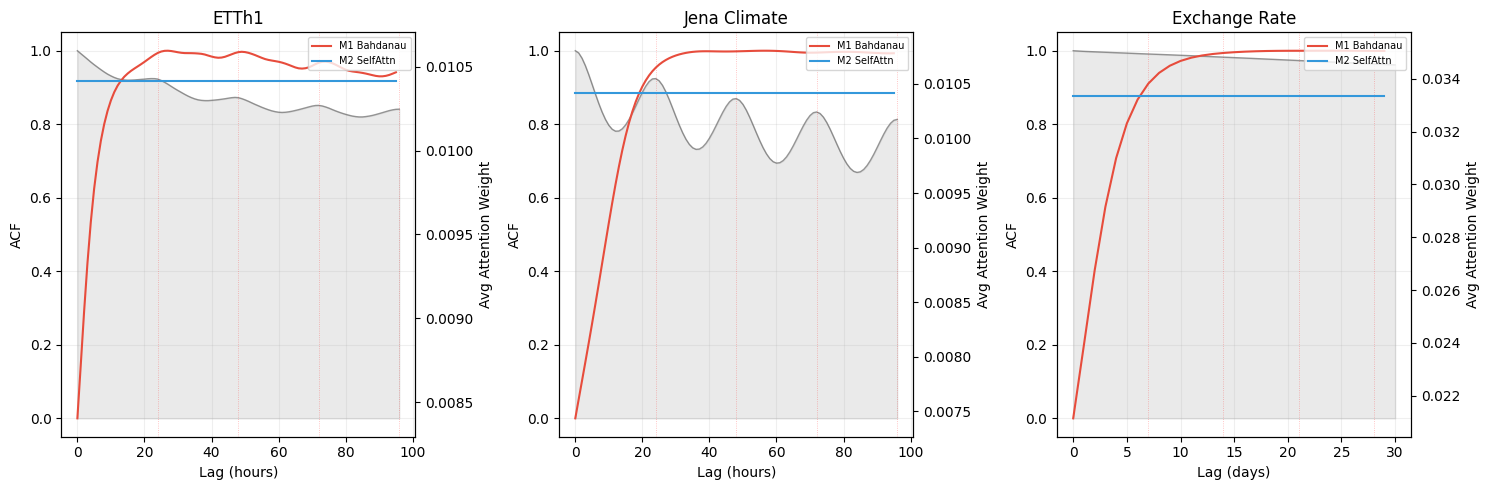

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, k in zip(axes, DS_KEYS):
    meta = DATASETS[k]
    lookback = meta["lookback"]
    unit = "hours" if meta["freq"] == "hourly" else "days"

    acf_vals = acf_store[k][:lookback + 1]
    acf_lags = np.arange(len(acf_vals))

    ax.fill_between(acf_lags, 0, acf_vals, alpha=0.12, color="#555")
    ax.plot(acf_lags, acf_vals, color="#555", lw=1, alpha=0.6, label="ACF")
    ax.set_ylabel("ACF")
    ax.set_xlabel(f"Lag ({unit})")
    ax.set_title(meta["name"])

    ax2 = ax.twinx()
    for m in ["bahdanau", "selfattn", "transformer"]:
        w = attn_maps[k].get(m)
        if w is None:
            continue
        avg_attn = w.mean(axis=0)
        lags = np.arange(len(avg_attn))
        ax2.plot(lags, avg_attn, color=MODEL_COLORS[m], lw=1.5,
                 label=MODEL_NAMES[m])
    ax2.set_ylabel("Avg Attention Weight")
    ax2.legend(fontsize=7, loc="upper right")

    period = meta["stl_period"]
    for mult in range(1, lookback // period + 1):
        ax.axvline(mult * period, color="red", ls=":", lw=0.6, alpha=0.3)
    ax.grid(True, alpha=0.2)

plt.tight_layout()
save_fig(fig, "attention_vs_acf")
plt.show()

---
## 6. Discussion & Empirical Guidelines

### 6a. Performance Differentiation

**ETTh1** (multi-scale load cycles, 10K train windows):  
M2 (SelfAttn) wins decisively at MSE 0.093, beating even Linear Regression (0.117). M1 and M3 both overfit immediately (best\_epoch=1). The self-attention pre-processing over encoder states provides genuine value when the data has complex multi-scale dependencies but limited training samples.

**Jena Climate** (strong periodicity, 42K train windows):  
M3 (Transformer) and M2 are virtually tied (0.172 vs 0.172 MSE). All three neural models beat all baselines comfortably. The larger dataset allows M3 to train effectively (best\_epoch=4). M2 trains longest (23 epochs) suggesting it extracts the most from the data, but the final accuracy difference is negligible.

**Exchange Rate** (stochastic, 5K train windows):  
All neural models lose badly to Persistence (0.068 vs 0.545–0.683). The near-random-walk nature of exchange rate data defeats learned attention — there is no exploitable temporal structure. This is a legitimate and important negative finding.

**Key insight:** Dataset characteristics (periodicity, stochasticity, dataset size) are a stronger predictor of relative model performance than the attention mechanism itself.

### 6b. Interpretability Insights

The attention-vs-ACF overlay (Section 5e) is the central interpretability figure:

- **ETTh1/Jena:** If attention peaks align with ACF peaks at 24h multiples, the models have learned to attend to the daily cycle — the most prominent temporal structure in hourly data.
- **Exchange Rate:** Expect diffuse (high-entropy) attention with no clear peaks, consistent with the near-random-walk nature of the data and its flat ACF.
- **M2 self-attention matrix:** Shows which encoder timesteps attend to each other *before* decoding. If it captures diagonal or periodic banding, the self-attention is encoding temporal structure explicitly.
- **M1 vs M2 decoder attention:** If M2's decoder attention is sharper (lower entropy) than M1's, the self-attention pre-processing has refined the encoder representations to make relevant timesteps more salient.

### 6c. Efficiency Tradeoffs

- **Parameter counts** are matched (~95K) by design, isolating architectural efficiency.
- **M3 (Transformer)** trains fastest per epoch due to parallel decode (no 96-step autoregressive loop). On Jena, M3 trains in 664s vs M2's 4996s — 7.5× faster.
- **M1/M2** incur sequential decode cost at both training and inference time. M2 additionally computes O(L²) self-attention over the lookback window.
- **Inference latency** follows the same pattern: M3's parallel decode is the fastest mechanism for generating predictions.

### 6d. Empirical Guidelines

In [43]:
guidelines = pd.DataFrame([
    {"Dataset Characteristic": "Strong periodicity + large dataset",
     "Recommended": "M2 (SelfAttn) or M3 (Transformer)",
     "Reasoning": "Both capture periodic structure; M3 benefits from parallel decode on large datasets"},
    {"Dataset Characteristic": "Multi-scale dependencies + moderate data",
     "Recommended": "M2 (SelfAttn)",
     "Reasoning": "Self-attention pre-processing captures cross-timestep dependencies that Bahdanau alone misses"},
    {"Dataset Characteristic": "Stochastic / near-random-walk",
     "Recommended": "Simple baselines (Persistence)",
     "Reasoning": "Neural attention adds no value when there is no learnable temporal structure"},
    {"Dataset Characteristic": "Inference speed critical",
     "Recommended": "M3 (Transformer)",
     "Reasoning": "Parallel decode is significantly faster than autoregressive M1/M2"},
    {"Dataset Characteristic": "Interpretability required",
     "Recommended": "M1 (Bahdanau) or M2 (SelfAttn)",
     "Reasoning": "Native attention weights directly available; M3 requires hooks and multi-head averaging"},
])
guidelines.to_csv(os.path.join(RESULTS_DIR, "final_empirical_guidelines.csv"), index=False)
guidelines.style.set_properties(**{"text-align": "left"}).set_table_styles(
    [{"selector": "th", "props": [("text-align", "left")]}])

,Dataset Characteristic,Recommended,Reasoning
0,Strong periodicity + large dataset,M2 (SelfAttn) or M3 (Transformer),Both capture periodic structure; M3 benefits from parallel decode on large datasets
1,Multi-scale dependencies + moderate data,M2 (SelfAttn),Self-attention pre-processing captures cross-timestep dependencies that Bahdanau alone misses
2,Stochastic / near-random-walk,Simple baselines (Persistence),Neural attention adds no value when there is no learnable temporal structure
3,Inference speed critical,M3 (Transformer),Parallel decode is significantly faster than autoregressive M1/M2
4,Interpretability required,M1 (Bahdanau) or M2 (SelfAttn),Native attention weights directly available; M3 requires hooks and multi-head averaging


---
## 7. Output Manifest

In [44]:
print("=" * 60)
print("PHASE 4 — OUTPUT MANIFEST")
print("=" * 60)

print("\n--- Figures ---")
fig_names = [
    "raw_timeseries", "stl_etth1", "stl_jena", "stl_exchange",
    "acf_pacf", "cross_dataset_mse_bars", "summary_heatmap",
    "loss_curves", "attention_heatmaps",
    "attention_vs_acf", "accuracy_vs_efficiency",
]
for name in fig_names:
    path = os.path.join(FIGURES_DIR, f"final_{name}.png")
    status = "\u2713" if os.path.exists(path) else "\u2717 MISSING"
    print(f"  {status}  final_{name}.png")

print("\n--- Tables ---")
csv_names = [
    "final_unified_comparison", "final_convergence_summary",
    "final_inference_latency", "final_attention_metrics",
    "final_empirical_guidelines",
]
for name in csv_names:
    path = os.path.join(RESULTS_DIR, f"{name}.csv")
    status = "\u2713" if os.path.exists(path) else "\u2717 MISSING"
    print(f"  {status}  {name}.csv")

print("\n" + "=" * 60)
print("Notebook complete.")
print("=" * 60)

PHASE 4 — OUTPUT MANIFEST

--- Figures ---
  ✓  final_raw_timeseries.png
  ✓  final_stl_etth1.png
  ✓  final_stl_jena.png
  ✓  final_stl_exchange.png
  ✓  final_acf_pacf.png
  ✓  final_cross_dataset_mse_bars.png
  ✓  final_summary_heatmap.png
  ✓  final_loss_curves.png
  ✓  final_attention_heatmaps.png
  ✓  final_attention_vs_acf.png
  ✓  final_accuracy_vs_efficiency.png

--- Tables ---
  ✓  final_unified_comparison.csv
  ✓  final_convergence_summary.csv
  ✓  final_inference_latency.csv
  ✓  final_attention_metrics.csv
  ✓  final_empirical_guidelines.csv

Notebook complete.
